In [1]:
# importing required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import kagglehub # library to pull Kaggle data directly in Colab

In [2]:
# step 01
# If a GPU is listed, Keras will automatically use it during training.
# Check that TensorFlow can see your GPU(s)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

# (Optional) Enable memory growth so TF doesn’t grab all GPU memory at once
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print("Memory growth error:", e)
else:
    print("No GPU detected, training will run on CPU.")

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled for GPUs.


In [3]:
# step 02
# Download CIFAR-10 dataset from Kaggle (RGB 32x32 images). (32, 32, 3)
path = kagglehub.dataset_download("ayush1220/cifar10")
print("Dataset downloaded to:", path)

data_dir = path  # from kagglehub.dataset_download

print("Version dir:", data_dir)
print("Inside version dir:", os.listdir(data_dir))

inner_dir = os.path.join(data_dir, "cifar10")
print("Inner dir:", inner_dir)
print("Inside inner dir:", os.listdir(inner_dir))

Using Colab cache for faster access to the 'cifar10' dataset.
Dataset downloaded to: /kaggle/input/cifar10
Version dir: /kaggle/input/cifar10
Inside version dir: ['cifar10']
Inner dir: /kaggle/input/cifar10/cifar10
Inside inner dir: ['test', 'train']


In [4]:
# step 03
# loading train data into train_dir and test data into test_dir
version_dir = "/root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2"
data_dir = os.path.join(version_dir, "cifar10")
train_dir = os.path.join(data_dir, "train")
test_dir  = os.path.join(data_dir, "test")

print("Train dir:", train_dir)
print("Test dir:", test_dir)
print("Train classes:", os.listdir(train_dir))

Train dir: /root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2/cifar10/train
Test dir: /root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2/cifar10/test
Train classes: ['ship', 'horse', 'automobile', 'truck', 'bird', 'cat', 'airplane', 'dog', 'deer', 'frog']


In [5]:
# step 04
# creating tf.data.Dataset by loading train dataset from train_dir and test dataset from test_dir
# later train dataset splits into train and validation dataset

img_size = (32, 32)
batch_size = 64

# Train+val from train_dir (Keras will infer class names from subfolders)
train_val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.2,  # 80% train, 20% val from training data
    subset="both",
    seed=42,
)

train_ds, val_ds = train_val_ds

# Test from test_dir
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,
)

Found 50000 files belonging to 10 classes.
Using 40000 files for training.
Using 10000 files for validation.
Found 10000 files belonging to 10 classes.


In [7]:
# step 05
# creating list of class names and checking total number of classes (required for model build)
class_names = train_ds.class_names
print("Class names:", class_names)
num_classes = len(class_names)
print(f"Number of classes {num_classes}")

Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes 10


Batch images shape: (64, 32, 32, 3)
Batch labels shape: (64,)


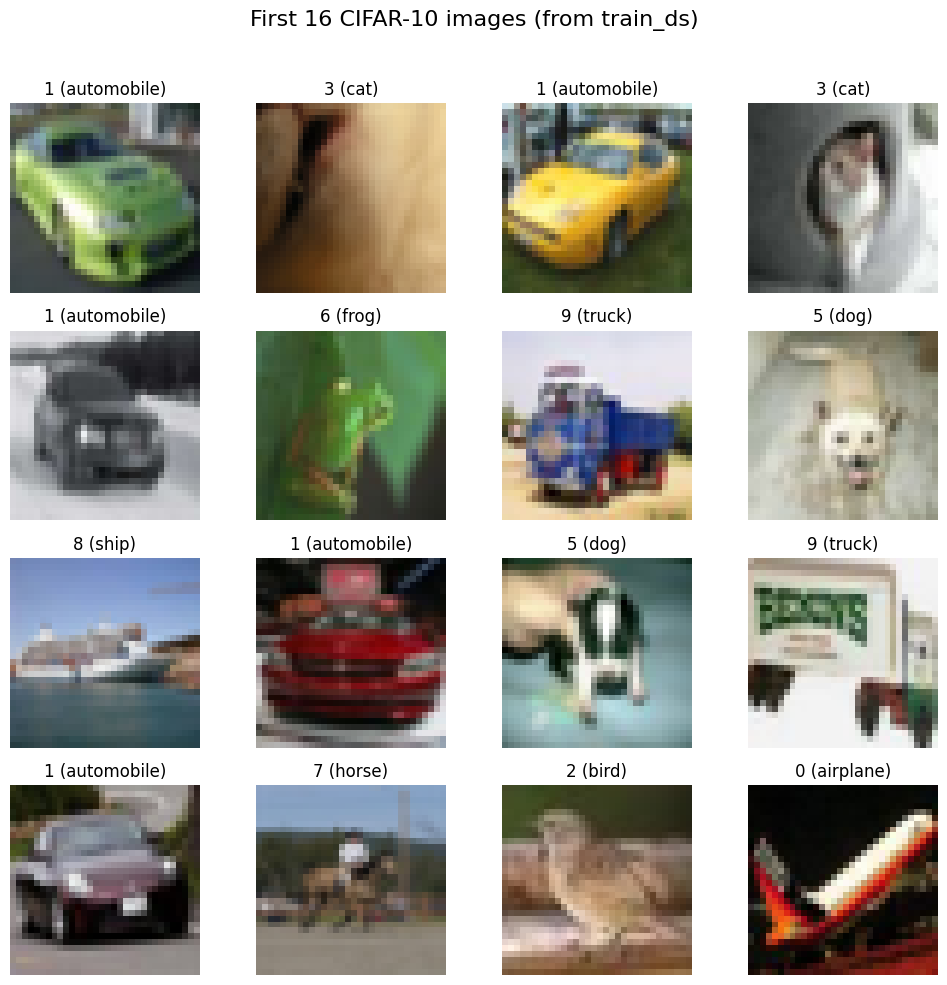

In [8]:
# step 06
# visualizing first 16 CIFAR-10 image data

import matplotlib.pyplot as plt

images_batch, labels_batch = next(iter(train_ds))
print("Batch images shape:", images_batch.shape)
print("Batch labels shape:", labels_batch.shape)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 CIFAR-10 images (from train_ds)", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i >= images_batch.shape[0]:
        break
    img = images_batch[i].numpy().astype("uint8")
    label_idx = int(labels_batch[i])
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{label_idx} ({class_names[label_idx]})")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [9]:
# step 07
# Normalizing data (CNNs usually work better when input pixels are normalized to [0, 1].)

normalization_layer = layers.Rescaling(1.0 / 255.0)

def norm_map(x, y):
    return normalization_layer(x), y

train_ds = train_ds.map(norm_map).cache().prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(norm_map).cache().prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(norm_map).cache().prefetch(tf.data.AUTOTUNE)

In [10]:
# step 08
# Defining Data augmentation block:
# Applied on-the-fly during training, helps generalization by making random small changes to input images.

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),   # randomly flip images left-right
        layers.RandomRotation(0.1),        # small random rotations
        layers.RandomZoom(0.1),            # random zoom in/out
    ],
    name="data_augmentation",
)

In [11]:
# step 09
# defining lambda value (L2 regularization factor (weight decay strength))
weight_decay = 1e-4

In [12]:
# step 10
# defining(creating) the model

def make_cnn_model(num_classes):
    # Input shape for CIFAR-10 RGB images
    inputs = keras.Input(shape=(32, 32, 3), name="input_image")

    # Data augmentation (only active in training)
    x = data_augmentation(inputs)

    # First conv block: two conv layers to learn richer local features,
    # then pooling + dropout to downsample and reduce overfitting.
    x = layers.Conv2D(
        32, (3, 3), padding="same", activation="relu",
        kernel_regularizer=keras.regularizers.l2(weight_decay),
        name="conv1",
        )(x)

    x = layers.Conv2D(
        32, (3, 3), padding="same", activation="relu",
        kernel_regularizer=keras.regularizers.l2(weight_decay),
        name="conv2",
        )(x)

    x = layers.MaxPooling2D((2, 2), name="pool1")(x)

    x = layers.Dropout(0.25, name="dropout1")(x)  # dropout for regularization

    # Second conv block: more filters to learn higher-level features,
    # then pooling + dropout to further compress and regularize the representation.

    x = layers.Conv2D(
        64, (3, 3), padding="same", activation="relu",
        kernel_regularizer=keras.regularizers.l2(weight_decay),
        name="conv3",
        )(x)

    x = layers.Conv2D(
        64, (3, 3), padding="same", activation="relu",
        kernel_regularizer=keras.regularizers.l2(weight_decay),
        name="conv4",
        )(x)

    x = layers.MaxPooling2D((2, 2), name="pool2")(x)

    x = layers.Dropout(0.25, name="dropout2")(x)

    # Classifier head: flatten features and use dense layers to map them to class probabilities.

    x = layers.Flatten(name="flatten")(x)

    x = layers.Dense(
        256, activation="relu",
        kernel_regularizer=keras.regularizers.l2(weight_decay),
        name="dense1",
        )(x)

    x = layers.Dropout(0.5, name="dropout3")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="cifar10_cnn")

    return model

model = make_cnn_model(num_classes)
model.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,116,970 (4.26 MB)

 Trainable params: 1,116,970 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# step 11
# Compiling the model with Adam and sparse categorical crossentropy
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [15]:
# step 12
# training the model with epoch 20

epochs = 20

callbacks = [
    # EarlyStopping: stop training if val_loss(monitor) doesn’t improve for 5 epochs(patience),
    # and restore the model weights from the epoch with the best val_loss)(restore_best_weights).

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    # ReduceLROnPlateau: if val_loss(monitor) stops improving for 2 epochs(patience),
    # cut the learning rate in half(factor) to help the optimizer make finer updates.

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,                # already batched & augmented in-model
    epochs=epochs,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/20
625/625 - 17s - 27ms/step - accuracy: 0.3516 - loss: 1.8201 - val_accuracy: 0.4475 - val_loss: 1.5826 - learning_rate: 0.0010
Epoch 2/20
625/625 - 7s - 12ms/step - accuracy: 0.4672 - loss: 1.5424 - val_accuracy: 0.5101 - val_loss: 1.4397 - learning_rate: 0.0010
Epoch 3/20
625/625 - 7s - 12ms/step - accuracy: 0.5101 - loss: 1.4401 - val_accuracy: 0.5639 - val_loss: 1.3025 - learning_rate: 0.0010
Epoch 4/20
625/625 - 7s - 11ms/step - accuracy: 0.5385 - loss: 1.3781 - val_accuracy: 0.5904 - val_loss: 1.2469 - learning_rate: 0.0010
Epoch 5/20
625/625 - 11s - 17ms/step - accuracy: 0.5607 - loss: 1.3294 - val_accuracy: 0.6123 - val_loss: 1.1866 - learning_rate: 0.0010
Epoch 6/20
625/625 - 7s - 12ms/step - accuracy: 0.5752 - loss: 1.2997 - val_accuracy: 0.6385 - val_loss: 1.1097 - learning_rate: 0.0010
Epoch 7/20
625/625 - 7s - 11ms/step - accuracy: 0.5901 - loss: 1.2761 - val_accuracy: 0.6340 - val_loss: 1.1496 - learning_rate: 0.0010
Epoch 8/20

Epoch 8: ReduceLROnPlateau reducin

In [16]:
# step 13
# Evaluating the model
test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

157/157 - 2s - 10ms/step - accuracy: 0.7122 - loss: 0.9226
Test loss: 0.9225517511367798
Test accuracy: 0.7121999859809875
